
# # Diabetes Readmission RL Project
# Objectif : prédire et optimiser la réadmission des patients diabétiques (30 jours)
# Approche : Reinforcement Learning (RL)



In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

sns.set(style="whitegrid")

## Business Understanding

### BO1 — Réduire les réadmissions hospitalières
- Identifier les patients à risque pour prévenir complications et coûts.

### BO2 — Optimiser la prise de décision clinique
- Recommander des interventions adaptées pour diminuer les réadmissions.

## Data Science Objectives

### DSO1 — Prédire la réadmission
- Entrées : âge, sexe, race, hospitalisation, diagnostics, traitements.
- Sortie : probabilité de réadmission <30 jours.

### DSO2 — Politique de décision séquentielle (RL)
- Optimiser actions hospitalières (médicaments, tests, suivi) pour minimiser les réadmissions.
- Reward : réadmission évitée + coût + qualité soins.

## Data Understanding

In [8]:
data_path = r"C:\Users\ayoub\Desktop\diabetes+130-us+hospitals+for+years+1999-2008\diabetic_data.csv"
ids_path = r"C:\Users\ayoub\Desktop\diabetes+130-us+hospitals+for+years+1999-2008\IDS_mapping.csv"

# Chargement
df = pd.read_csv(data_path)
ids_df = pd.read_csv(ids_path)

# Aperçu
print("Dimensions du dataset :", df.shape)
print("Colonnes :", df.columns.tolist())
df.head(5)

Dimensions du dataset : (101766, 50)
Colonnes : ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


Distribution readmission :
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


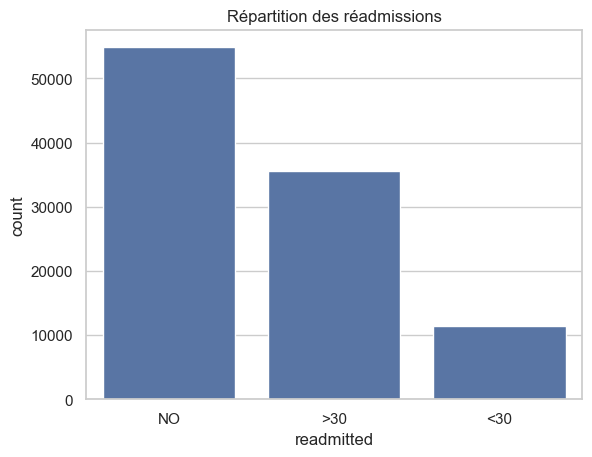

In [9]:
print("Distribution readmission :")
print(df['readmitted'].value_counts())

sns.countplot(x='readmitted', data=df)
plt.title("Répartition des réadmissions")
plt.show()

In [10]:
# Types de données
print(df.dtypes)

# Statistiques descriptives pour colonnes numériques
df.describe().T

# Vérification valeurs manquantes
missing = df.isnull().sum()
missing[missing>0]

categorical_cols = ['race','gender','age','admission_type_id','discharge_disposition_id','admission_source_id','medical_specialty','diabetesMed']
for col in categorical_cols:
    print(f"=== {col} ===")
    print(df[col].value_counts())
    print("\n")

  

encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride         

## Data Preparation

In [11]:
df_prep = df.copy()

# Remplacer les "?" par NaN
df_prep = df_prep.replace("?", np.nan)

# 1️⃣ Identifier colonnes numériques / catégorielles
num_cols = df_prep.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df_prep.select_dtypes(include=["object"]).columns.tolist()

# La target est catégorielle aussi
if "readmitted" not in cat_cols:
    cat_cols.append("readmitted")

# 2️⃣ Encodage LabelEncoder pour TOUTES les colonnes catégorielles
# (Plus adapté pour Reinforcement Learning que One-Hot)
le_dict = {}

for col in cat_cols:
    le = LabelEncoder()
    df_prep[col] = le.fit_transform(df_prep[col].astype(str))
    le_dict[col] = le

# 3️⃣ Imputation médiane sur toutes les colonnes numériques
for col in num_cols:
    df_prep[col] = df_prep[col].fillna(df_prep[col].median())

# Vérification
df_prep.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,2,0,0,9,6,25,1,1,...,0,1,1,0,0,0,0,1,0,2
1,149190,55629189,2,0,1,9,1,1,7,3,...,0,3,1,0,0,0,0,0,1,1
2,64410,86047875,0,0,2,9,1,1,7,2,...,0,1,1,0,0,0,0,1,1,2
3,500364,82442376,2,1,3,9,1,1,7,2,...,0,3,1,0,0,0,0,0,1,2
4,16680,42519267,2,1,4,9,1,1,7,1,...,0,2,1,0,0,0,0,0,1,2
